# Scratch Vibe Coder — Experiment Analysis

This notebook analyzes only complete six-model experiments stored in PostgreSQL: an experiment is included only when it has a recorded result from every model in `MODELS`. It covers record coverage, trial counts, API reliability, error rates, truncation, latency, token usage, reviewer feedback, functional correctness, intent alignment, outcomes, model rankings, difficulty effects, and per-experiment comparisons.

Important: `status = success` means the model API returned a response. It does **not** prove that the XML was valid or insertable. Reviewed outcomes and truncation indicators are therefore reported separately. `EXP-004` is excluded from the analysis by design.

## 1. Setup

The first code cell checks the active Jupyter kernel and installs only missing packages before the analysis imports run.

In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sqlalchemy': 'sqlalchemy',
    'psycopg2': 'psycopg2-binary',
    'jinja2': 'jinja2',
}
missing_packages = [
    package for module, package in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    print('Installing missing notebook dependencies:', ', '.join(missing_packages))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *missing_packages])
else:
    print('All notebook dependencies are already installed.')


All notebook dependencies are already installed.


In [2]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from sqlalchemy import create_engine

get_ipython().run_line_magic('matplotlib', 'inline')

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 140)
sns.set_theme(style='whitegrid', context='notebook')

DATABASE_URL = os.getenv('DATABASE_URL', 'postgresql://localhost:5432/scratch_viber')
if DATABASE_URL.startswith('postgres://'):
    DATABASE_URL = DATABASE_URL.replace('postgres://', 'postgresql+psycopg2://', 1)
elif DATABASE_URL.startswith('postgresql://'):
    DATABASE_URL = DATABASE_URL.replace('postgresql://', 'postgresql+psycopg2://', 1)
EXCLUDED_EXPERIMENT_IDS = {'EXP-004'}

MODELS = {
    'meta-llama/Llama-3.3-70B-Instruct:groq': 'Llama 3.3 70B',
    'Qwen/Qwen3-Next-80B-A3B-Instruct:novita': 'Qwen3 Next 80B',
    'moonshotai/Kimi-K3:together': 'Kimi K3',
    'deepseek-ai/DeepSeek-V4-Flash-0731:novita': 'DeepSeek V4 Flash',
    'google/gemma-4-31B-it:novita': 'Gemma 4 31B',
    'openai/gpt-oss-120b:groq': 'GPT-OSS 120B',
}
MODEL_ORDER = list(MODELS.values())
DIFFICULTY_ORDER = ['Easy', 'Medium', 'Hard']

engine = create_engine(DATABASE_URL)


## 2. Load and prepare the experiment records

In [3]:
quoted_models = ', '.join("'" + model.replace("'", "''") + "'" for model in MODELS)
query = f'''
SELECT
    request_id, created_at, experiment_id, difficulty, model, provider, prompt,
    response, response_json, status, http_status, error, latency_ms,
    provider_latency_ms, prompt_tokens, completion_tokens, total_tokens,
    parameters, functional_correctness, intent_alignment, outcome,
    feedback_notes, feedback_created_at
FROM hf_requests
WHERE model IN ({quoted_models})
ORDER BY created_at
'''

df = pd.read_sql_query(query, engine)
df = df[~df['experiment_id'].isin(EXCLUDED_EXPERIMENT_IDS)].copy()
model_counts = df.groupby('experiment_id')['model'].nunique()
complete_experiment_ids = model_counts[model_counts == len(MODELS)].index
df = df[df['experiment_id'].isin(complete_experiment_ids)].copy()
df['created_at'] = pd.to_datetime(df['created_at'], utc=True)
df['model_label'] = df['model'].map(MODELS).fillna(df['model'])
df['difficulty'] = pd.Categorical(df['difficulty'], DIFFICULTY_ORDER, ordered=True)
df['user_prompt'] = (df['prompt'].fillna('')
                     .str.split(r'\nUser request:\s*', regex=True)
                     .str[-1].str.strip())

df['api_success'] = df['status'].str.lower().eq('success')
df['api_error'] = ~df['api_success']
df['has_response'] = df['response'].fillna('').str.strip().ne('')
df['has_any_feedback'] = df[['functional_correctness', 'intent_alignment', 'outcome']].notna().any(axis=1)
df['feedback_complete'] = df[['functional_correctness', 'intent_alignment', 'outcome']].notna().all(axis=1)

OUTCOME_SCORE = {
    'worked': 1.0,
    'partially worked': 0.5,
    'did not work': 0.0,
}
df['outcome_normalized'] = df['outcome'].fillna('').str.strip().str.lower()
df['outcome_score'] = df['outcome_normalized'].map(OUTCOME_SCORE)
df['functional_score'] = pd.to_numeric(df['functional_correctness'], errors='coerce') / 5
df['alignment_score'] = pd.to_numeric(df['intent_alignment'], errors='coerce') / 5

def finish_reason(value):
    if isinstance(value, str):
        try:
            value = json.loads(value)
        except (TypeError, json.JSONDecodeError):
            return None
    try:
        return value['choices'][0]['finish_reason']
    except (TypeError, KeyError, IndexError):
        return None

df['finish_reason'] = df['response_json'].apply(finish_reason)
df['truncated'] = df['finish_reason'].str.lower().eq('length')
df['non_truncated_response'] = df['api_success'] & df['has_response'] & ~df['truncated']

QUALITY_WEIGHTS = {'functional_score': 0.45, 'alignment_score': 0.35, 'outcome_score': 0.20}
def weighted_quality(row):
    available = [(row[column], weight) for column, weight in QUALITY_WEIGHTS.items() if pd.notna(row[column])]
    if not available:
        return np.nan
    return sum(value * weight for value, weight in available) / sum(weight for _, weight in available)

df['quality_score'] = df.apply(weighted_quality, axis=1)
print(f'{len(df):,} records loaded across {df.experiment_id.nunique()} experiments and {df.model.nunique()} models.')


310 records loaded across 35 experiments and 6 models.


## 3. Dataset integrity and feedback completeness

These checks catch analysis problems before model comparisons are calculated.

In [4]:
integrity = pd.Series({
    'records': len(df),
    'unique request IDs': df['request_id'].nunique(),
    'duplicate request IDs': df['request_id'].duplicated().sum(),
    'experiments': df['experiment_id'].nunique(),
    'models': df['model'].nunique(),
    'records missing experiment ID': df['experiment_id'].isna().sum(),
    'records missing difficulty': df['difficulty'].isna().sum(),
    'records with any feedback': df['has_any_feedback'].sum(),
    'records with complete feedback': df['feedback_complete'].sum(),
    'feedback coverage': df['has_any_feedback'].mean(),
    'truncated responses': df['truncated'].sum(),
})
display(integrity.to_frame('value'))

difficulty_conflicts = (df.groupby('experiment_id', observed=True)['difficulty']
                        .nunique(dropna=True).loc[lambda values: values > 1])
if len(difficulty_conflicts):
    display(Markdown('**Warning:** Some experiment IDs have conflicting difficulty values.'))
    display(difficulty_conflicts)
else:
    display(Markdown('✓ Every experiment ID has one consistent difficulty level.'))


,value
records,310.000000
unique request IDs,310.000000
duplicate request IDs,0.000000
experiments,35.000000
models,6.000000
records missing experiment ID,0.000000
records missing difficulty,0.000000
records with any feedback,216.000000
records with complete feedback,216.000000
feedback coverage,0.696774


✓ Every experiment ID has one consistent difficulty level.

## 4. Record coverage and trial counts

Coverage counts every stored request, including failures. API success is analyzed separately.

,trials,experiments_recorded,api_successes,api_errors,responses,truncated,reviewed,complete_reviews,record_coverage,feedback_coverage
model_label,,,,,,,,,,
Llama 3.3 70B,49,35,48,1,48,3,36,36,100.0%,73.5%
Qwen3 Next 80B,48,35,48,0,48,9,34,34,100.0%,70.8%
Kimi K3,50,35,49,1,49,9,35,35,100.0%,70.0%
DeepSeek V4 Flash,52,35,52,0,26,28,32,32,100.0%,61.5%
Gemma 4 31B,46,35,20,26,20,1,42,42,100.0%,91.3%
GPT-OSS 120B,65,35,65,0,62,11,37,37,100.0%,56.9%


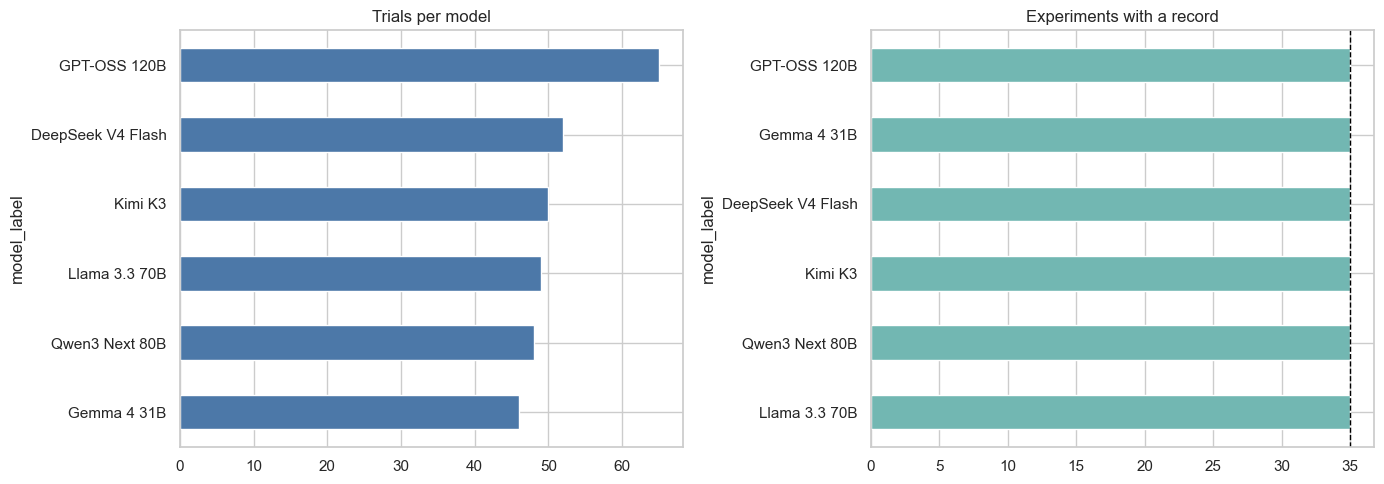

In [5]:
trials_by_model = (df.groupby('model_label', observed=True)
    .agg(
        trials=('request_id', 'count'),
        experiments_recorded=('experiment_id', 'nunique'),
        api_successes=('api_success', 'sum'),
        api_errors=('api_error', 'sum'),
        responses=('has_response', 'sum'),
        truncated=('truncated', 'sum'),
        reviewed=('has_any_feedback', 'sum'),
        complete_reviews=('feedback_complete', 'sum'),
    )
    .reindex(MODEL_ORDER))
trials_by_model['record_coverage'] = trials_by_model['experiments_recorded'] / df['experiment_id'].nunique()
trials_by_model['feedback_coverage'] = trials_by_model['reviewed'] / trials_by_model['trials']
display(trials_by_model.style.format({
    'record_coverage': '{:.1%}', 'feedback_coverage': '{:.1%}'
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
trials_by_model['trials'].sort_values().plot.barh(ax=axes[0], color='#4C78A8', title='Trials per model')
trials_by_model['experiments_recorded'].sort_values().plot.barh(ax=axes[1], color='#72B7B2', title='Experiments with a record')
axes[1].axvline(df['experiment_id'].nunique(), color='black', linestyle='--', linewidth=1)
plt.tight_layout()


In [6]:
all_models = set(MODELS)
recorded = df.groupby('experiment_id')['model'].agg(set)
coverage_gaps = pd.DataFrame({
    'recorded_models': recorded.apply(len),
    'missing_models': recorded.apply(lambda values: sorted(MODELS[m] for m in all_models - values)),
}).query('recorded_models < @df.model.nunique()')
display(coverage_gaps if len(coverage_gaps) else Markdown('✓ All included experiments have a record for all six models.'))


✓ All included experiments have a record for all six models.

## 5. API reliability, error rates, truncation, latency, and tokens

The Wilson interval expresses uncertainty around each API success rate. Repeated trials are retained because they are useful for reliability analysis.

,trials,api_successes,api_success_rate,error_rate,response_rate,non_truncated_response_rate,truncation_rate,mean_latency_ms,median_latency_ms,p95_latency_ms,mean_total_tokens,success_ci_low,success_ci_high
model_label,,,,,,,,,,,,,
Llama 3.3 70B,49,48,98.0%,2.0%,98.0%,91.8%,6.1%,"5,562","4,376","13,378","11,912",89.3%,99.6%
Qwen3 Next 80B,48,48,100.0%,0.0%,100.0%,81.2%,18.8%,"11,600","7,342","29,122","12,540",92.6%,100.0%
Kimi K3,50,49,98.0%,2.0%,98.0%,80.0%,18.0%,"34,414","20,169","88,162","12,253",89.5%,99.6%
DeepSeek V4 Flash,52,52,100.0%,0.0%,50.0%,46.2%,53.8%,"30,876","36,469","44,342","13,819",93.1%,100.0%
Gemma 4 31B,46,20,43.5%,56.5%,43.5%,41.3%,2.2%,"93,580","120,162","120,367","12,759",30.2%,57.8%
GPT-OSS 120B,65,65,100.0%,0.0%,95.4%,83.1%,16.9%,"5,586","4,626","9,766","13,266",94.4%,100.0%


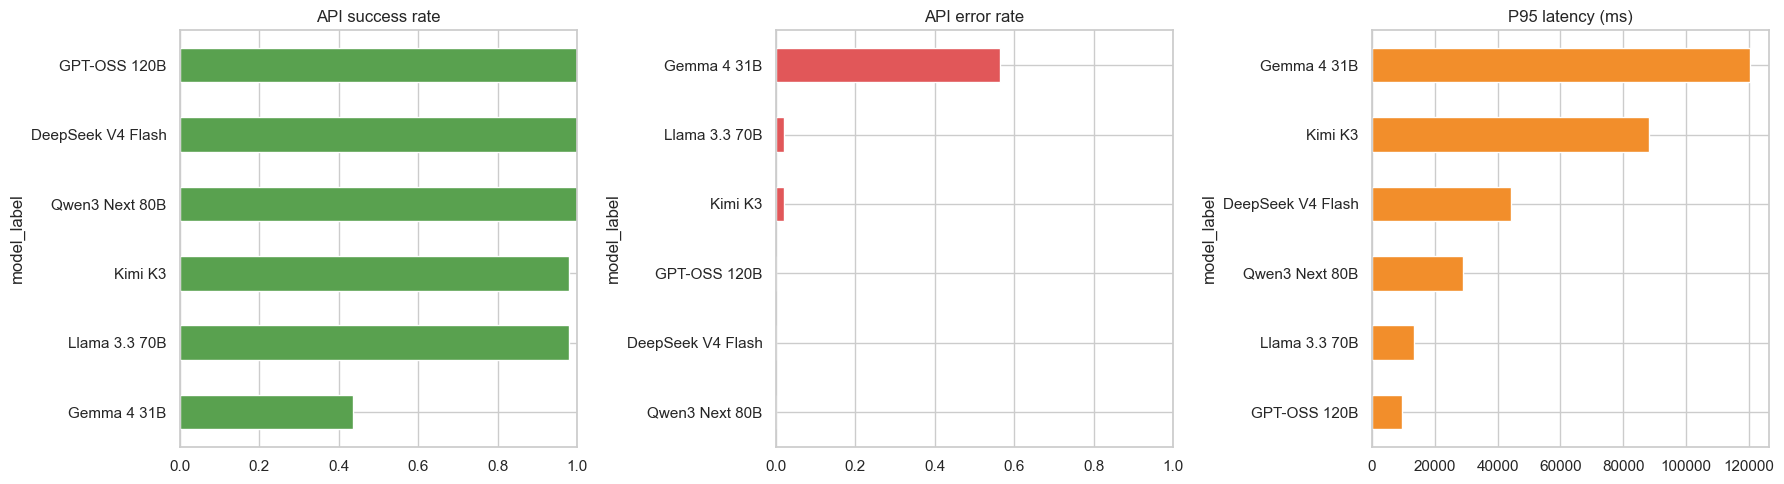

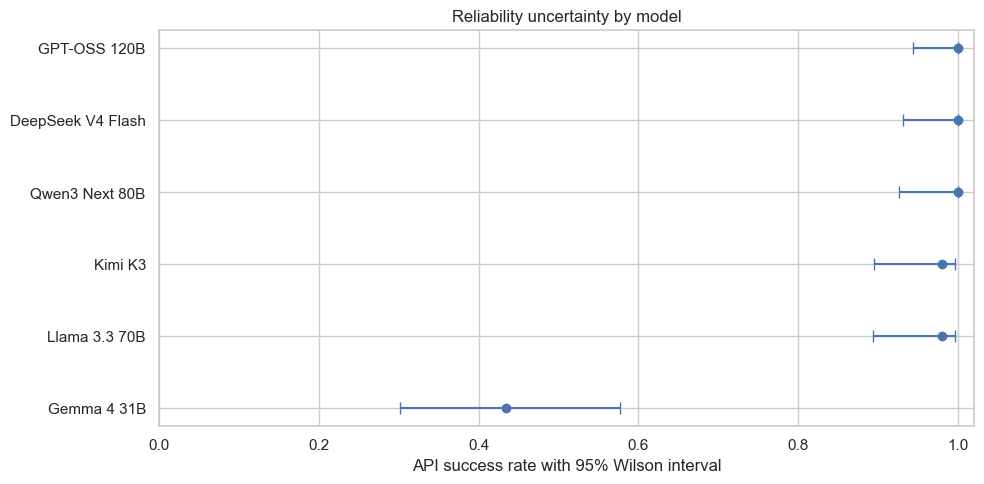

In [7]:
def wilson_interval(successes, trials, z=1.96):
    if not trials:
        return (np.nan, np.nan)
    p = successes / trials
    denominator = 1 + z**2 / trials
    center = (p + z**2 / (2 * trials)) / denominator
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * trials)) / trials) / denominator
    return center - margin, center + margin

reliability = (df.groupby('model_label', observed=True)
    .agg(
        trials=('request_id', 'count'),
        api_successes=('api_success', 'sum'),
        api_success_rate=('api_success', 'mean'),
        error_rate=('api_error', 'mean'),
        response_rate=('has_response', 'mean'),
        non_truncated_response_rate=('non_truncated_response', 'mean'),
        truncation_rate=('truncated', 'mean'),
        mean_latency_ms=('latency_ms', 'mean'),
        median_latency_ms=('latency_ms', 'median'),
        p95_latency_ms=('latency_ms', lambda values: values.quantile(0.95)),
        mean_total_tokens=('total_tokens', 'mean'),
    )
    .reindex(MODEL_ORDER))
intervals = reliability.apply(lambda row: wilson_interval(row.api_successes, row.trials), axis=1)
reliability[['success_ci_low', 'success_ci_high']] = pd.DataFrame(intervals.tolist(), index=reliability.index)
display(reliability.style.format({
    'api_success_rate': '{:.1%}', 'error_rate': '{:.1%}', 'response_rate': '{:.1%}',
    'non_truncated_response_rate': '{:.1%}', 'truncation_rate': '{:.1%}',
    'success_ci_low': '{:.1%}', 'success_ci_high': '{:.1%}',
    'mean_latency_ms': '{:,.0f}', 'median_latency_ms': '{:,.0f}',
    'p95_latency_ms': '{:,.0f}', 'mean_total_tokens': '{:,.0f}',
}))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
reliability['api_success_rate'].sort_values().plot.barh(ax=axes[0], color='#59A14F', title='API success rate')
reliability['error_rate'].sort_values().plot.barh(ax=axes[1], color='#E15759', title='API error rate')
reliability['p95_latency_ms'].sort_values().plot.barh(ax=axes[2], color='#F28E2B', title='P95 latency (ms)')
axes[0].set_xlim(0, 1); axes[1].set_xlim(0, 1)
plt.tight_layout()

ci_plot = reliability.sort_values('api_success_rate')
ci_errors = np.vstack([
    np.maximum(ci_plot['api_success_rate'] - ci_plot['success_ci_low'], 0),
    np.maximum(ci_plot['success_ci_high'] - ci_plot['api_success_rate'], 0),
])
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(ci_plot['api_success_rate'], ci_plot.index, xerr=ci_errors, fmt='o', capsize=4)
ax.set_xlim(0, 1.02)
ax.set_xlabel('API success rate with 95% Wilson interval')
ax.set_title('Reliability uncertainty by model')
plt.tight_layout()


error_category,Other,Provider/server,Rate limit
model_label,,,
Llama 3.3 70B,1,0,0
Qwen3 Next 80B,0,0,0
Kimi K3,0,1,0
DeepSeek V4 Flash,0,0,0
Gemma 4 31B,0,25,1
GPT-OSS 120B,0,0,0


,created_at,experiment_id,difficulty,model_label,http_status,error_category,error
272,2026-08-08 12:47:14.468955+00:00,EXP-032,Hard,Kimi K3,504,Provider/server,None
267,2026-08-07 00:01:22.859389+00:00,EXP-033,Hard,Gemma 4 31B,504,Provider/server,None
260,2026-08-06 23:49:59.311196+00:00,EXP-034,Hard,Gemma 4 31B,504,Provider/server,None
254,2026-08-06 23:37:10.619216+00:00,EXP-014,Medium,Gemma 4 31B,504,Provider/server,None
245,2026-08-06 23:26:54.284166+00:00,EXP-024,Medium,Gemma 4 31B,504,Provider/server,None
239,2026-08-06 23:18:27.771150+00:00,EXP-011,Medium,Gemma 4 31B,504,Provider/server,None
233,2026-08-06 22:21:54.267541+00:00,EXP-013,Medium,Gemma 4 31B,504,Provider/server,None
227,2026-08-06 22:15:03.121056+00:00,EXP-012,Medium,Gemma 4 31B,504,Provider/server,None
226,2026-08-06 22:14:03.800487+00:00,EXP-012,Medium,Gemma 4 31B,504,Provider/server,None
219,2026-08-06 22:06:36.658118+00:00,EXP-029,Medium,Gemma 4 31B,429,Rate limit,None


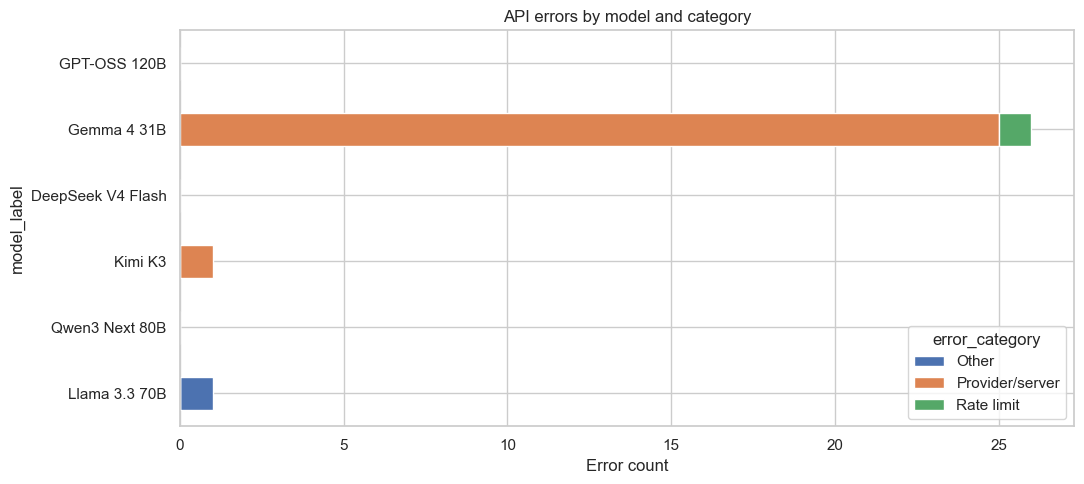

In [8]:
def error_category(row):
    if row['api_success']:
        return 'None'
    text = f"{row.get('error', '')} {row.get('http_status', '')}".lower()
    if 'timeout' in text or 'timed out' in text:
        return 'Timeout'
    if 'rate' in text or '429' in text:
        return 'Rate limit'
    if '401' in text or '403' in text or 'auth' in text or 'token' in text:
        return 'Authentication'
    if any(code in text for code in ['500', '502', '503', '504']):
        return 'Provider/server'
    if 'network' in text or 'fetch' in text or 'connection' in text:
        return 'Network'
    return 'Other'

df['error_category'] = df.apply(error_category, axis=1)
error_table = pd.crosstab(df.loc[df.api_error, 'model_label'], df.loc[df.api_error, 'error_category'])
error_table = error_table.reindex(MODEL_ORDER).fillna(0).astype(int)
display(error_table)
if error_table.to_numpy().sum():
    error_table.plot.barh(stacked=True, figsize=(11, 5), title='API errors by model and category')
    plt.xlabel('Error count')
    plt.tight_layout()

error_details = df.loc[df.api_error, [
    'created_at', 'experiment_id', 'difficulty', 'model_label', 'http_status', 'error_category', 'error'
]].sort_values('created_at', ascending=False)
display(error_details.head(30))


## 6. Reviewed output quality and model scoring

The row-level quality score combines functional correctness (45%), intent alignment (35%), and outcome (20%). Ratings are normalized to 0–1. Missing components are excluded and the remaining weights are renormalized. Always interpret scores together with the reviewed-trial count and feedback coverage.

The overall model score combines API reliability (30%), mean functional correctness (30%), mean intent alignment (25%), and outcome score (15%). This is an explicit analysis choice rather than an objective truth; adjust the weights for the research question.

,trials,reviewed_trials,mean_functional_correctness,mean_intent_alignment,worked_rate,did_not_work_rate,mean_outcome_score,mean_quality_score,quality_std,review_coverage,overall_model_score
model_label,,,,,,,,,,,
Kimi K3,50,35,4.14,4.26,0.771429,8.6%,0.843,0.839,0.250,0.700000,0.882
GPT-OSS 120B,65,37,3.32,3.38,0.729730,24.3%,0.743,0.684,0.332,0.569231,0.780
DeepSeek V4 Flash,52,32,3.09,3.22,0.562500,43.8%,0.562,0.616,0.404,0.615385,0.731
Llama 3.3 70B,49,36,2.83,3.00,0.361111,38.9%,0.486,0.562,0.320,0.734694,0.687
Qwen3 Next 80B,48,34,2.44,2.44,0.617647,26.5%,0.676,0.526,0.268,0.708333,0.670
Gemma 4 31B,46,42,1.98,2.17,0.214286,66.7%,0.274,0.384,0.325,0.913043,0.398


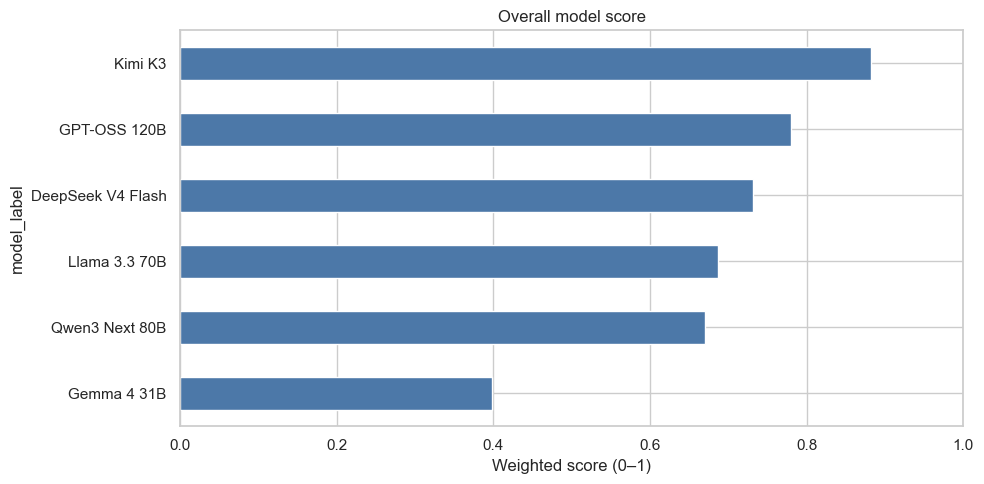

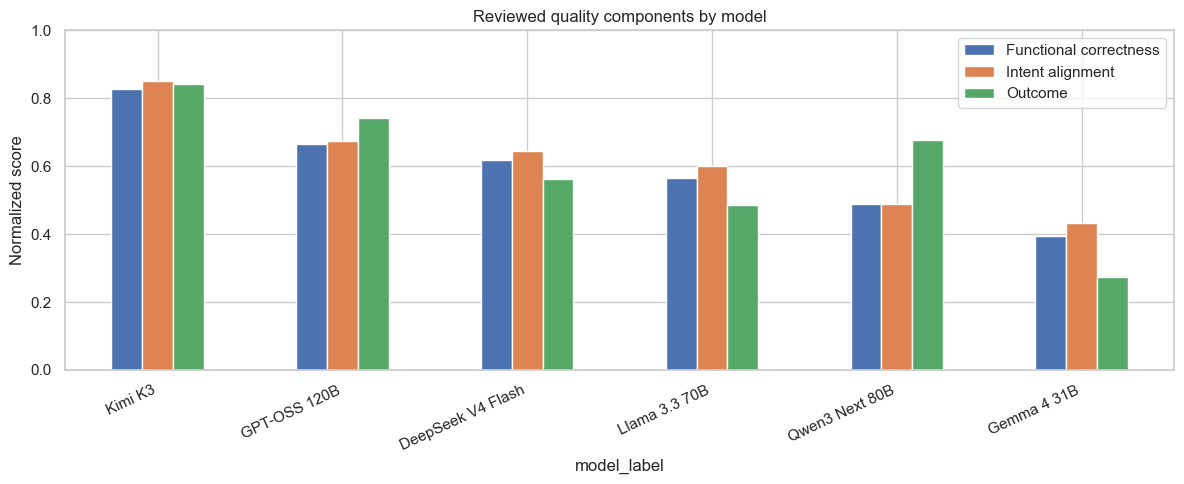

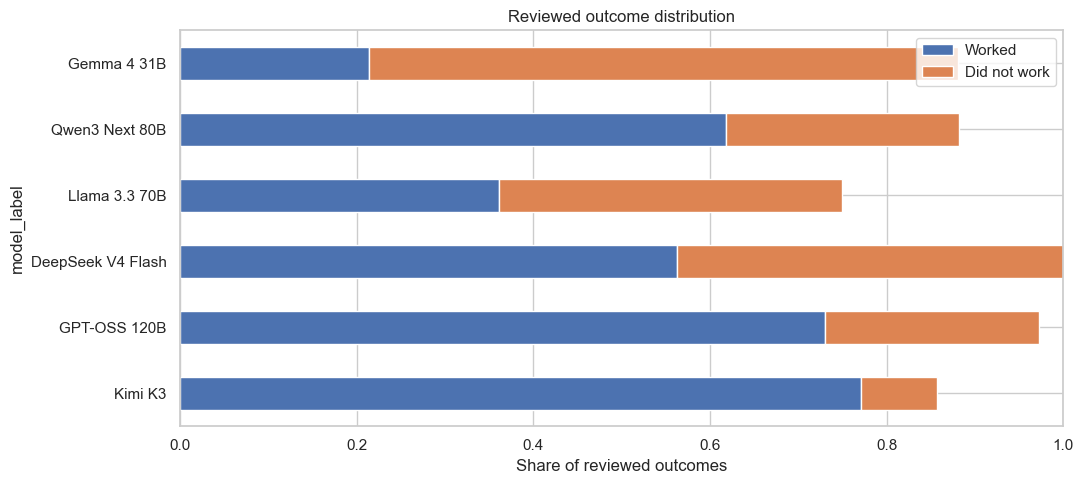

In [9]:
quality = (df.groupby('model_label', observed=True)
    .agg(
        trials=('request_id', 'count'),
        reviewed_trials=('quality_score', 'count'),
        mean_functional_correctness=('functional_correctness', 'mean'),
        mean_intent_alignment=('intent_alignment', 'mean'),
        worked_rate=('outcome_normalized', lambda values: values.eq('worked').sum() / values.ne('').sum() if values.ne('').sum() else np.nan),
        did_not_work_rate=('outcome_normalized', lambda values: values.eq('did not work').sum() / values.ne('').sum() if values.ne('').sum() else np.nan),
        mean_outcome_score=('outcome_score', 'mean'),
        mean_quality_score=('quality_score', 'mean'),
        quality_std=('quality_score', 'std'),
    )
    .reindex(MODEL_ORDER))
quality['review_coverage'] = quality['reviewed_trials'] / quality['trials']
quality['overall_model_score'] = (
    0.30 * reliability['api_success_rate'] +
    0.30 * (quality['mean_functional_correctness'] / 5) +
    0.25 * (quality['mean_intent_alignment'] / 5) +
    0.15 * quality['mean_outcome_score']
)
quality = quality.sort_values('overall_model_score', ascending=False)
display(quality.style.format({
    'did_not_work_rate': '{:.1%}', 'mean_outcome_score': '{:.3f}',
    'mean_quality_score': '{:.3f}', 'quality_std': '{:.3f}',
    'mean_functional_correctness': '{:.2f}', 'mean_intent_alignment': '{:.2f}',
    'overall_model_score': '{:.3f}',
}).background_gradient(subset=['overall_model_score'], cmap='YlGn'))

ax = quality['overall_model_score'].sort_values().plot.barh(
    figsize=(10, 5), color='#4C78A8', title='Overall model score'
)
ax.set_xlim(0, 1)
ax.set_xlabel('Weighted score (0–1)')
plt.tight_layout()

components = quality[[
    'mean_functional_correctness', 'mean_intent_alignment'
]].div(5).rename(columns={
    'mean_functional_correctness': 'Functional correctness',
    'mean_intent_alignment': 'Intent alignment',
})
components['Outcome'] = quality['mean_outcome_score']
components.plot.bar(figsize=(12, 5), ylim=(0, 1), title='Reviewed quality components by model')
plt.ylabel('Normalized score')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()

outcomes = quality[['worked_rate', 'did_not_work_rate']].rename(columns={
    'worked_rate': 'Worked', 'did_not_work_rate': 'Did not work'
})
outcomes.plot.barh(stacked=True, figsize=(11, 5), xlim=(0, 1), title='Reviewed outcome distribution')
plt.xlabel('Share of reviewed outcomes')
plt.tight_layout()


## 7. Per-experiment results

,difficulty,prompt,trials,models_recorded,api_success_rate,error_count,truncation_count,reviewed_trials,mean_functional_correctness,mean_intent_alignment,mean_outcome_score,mean_quality_score,median_latency_ms,feedback_coverage
experiment_id,,,,,,,,,,,,,,
EXP-001,Easy,"Say “Hello!” for 2 seconds, then move 100 steps.",16,6,68.8%,5,0,15,3.53,3.47,0.633,0.687,"15,698",93.8%
EXP-002,Easy,Move from the right to left indefinitely and go back,13,6,100.0%,0,2,8,3.88,3.75,0.750,0.761,"15,433",61.5%
EXP-003,Easy,Move the cat 10 steps,8,6,100.0%,0,0,6,5.00,5.00,1.000,1.000,"4,222",75.0%
EXP-005,Easy,"When Space is pressed, move upward and then fall back to the starting position. Prevent another jump while airborne.",8,6,87.5%,1,1,5,3.20,3.40,0.800,0.686,"6,774",62.5%
EXP-006,Easy,Move horizontally between two fixed x-coordinates without using edge-bounce blocks.,7,6,100.0%,0,1,5,4.20,4.40,1.000,0.886,"7,411",71.4%
EXP-007,Easy,"Start at 50% size, grow whenever clicked, and reset after reaching 150%.",6,6,100.0%,0,1,5,2.00,2.40,0.600,0.468,"7,798",83.3%
EXP-008,Easy,Give the player 15 seconds to click the randomly moving sprite as many times as possible.,9,6,88.9%,1,3,6,2.33,2.33,0.583,0.490,"36,323",66.7%
EXP-009,Easy,Move across the Stage while repeatedly switching between two costumes.,11,6,100.0%,0,1,6,4.33,4.33,0.917,0.877,"5,412",54.5%
EXP-010,Medium,Apply vertical velocity and gravity continuously. Allow jumping -on space click- only while the sprite is on the ground.,9,6,100.0%,0,2,5,3.00,3.40,0.800,0.668,"17,167",55.6%


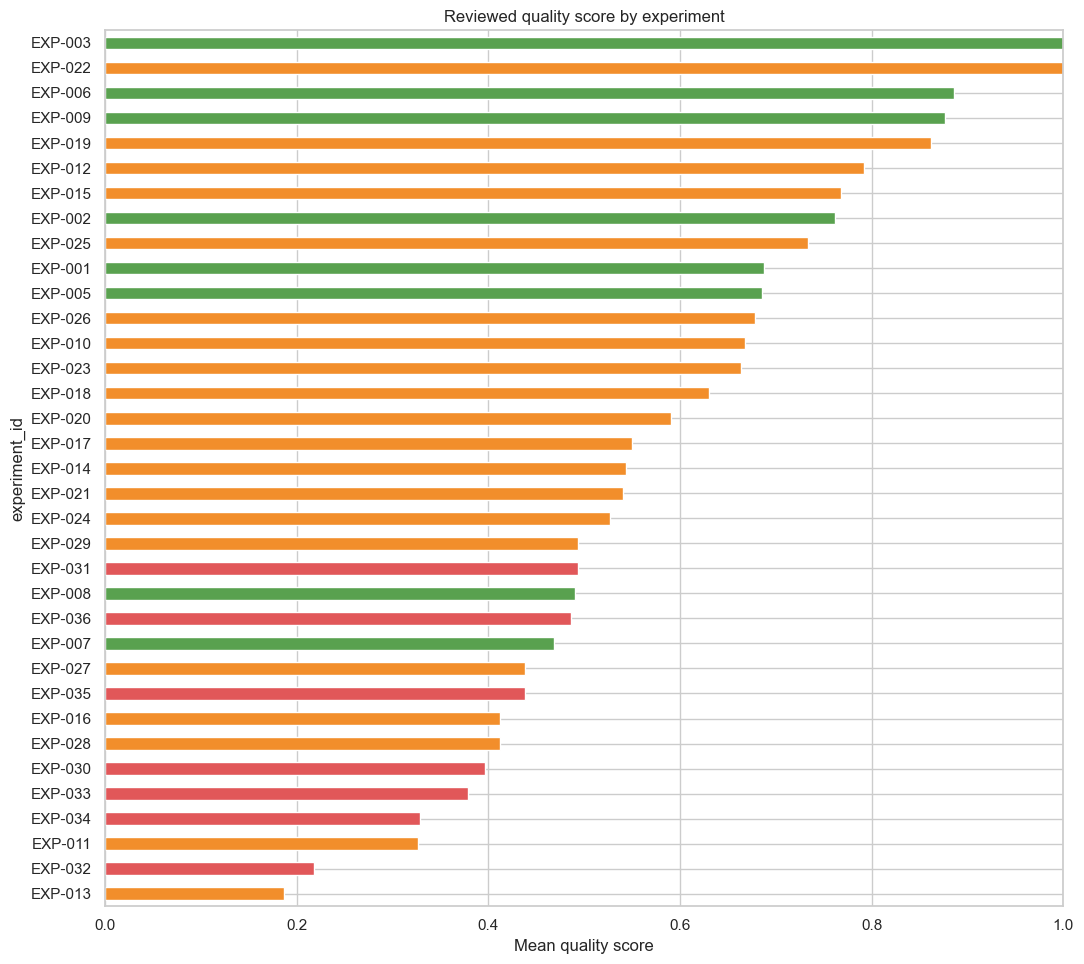

In [10]:
experiment_summary = (df.groupby('experiment_id', observed=True)
    .agg(
        difficulty=('difficulty', 'first'),
        prompt=('user_prompt', lambda values: values.value_counts().index[0]),
        trials=('request_id', 'count'),
        models_recorded=('model', 'nunique'),
        api_success_rate=('api_success', 'mean'),
        error_count=('api_error', 'sum'),
        truncation_count=('truncated', 'sum'),
        reviewed_trials=('quality_score', 'count'),
        mean_functional_correctness=('functional_correctness', 'mean'),
        mean_intent_alignment=('intent_alignment', 'mean'),
        mean_outcome_score=('outcome_score', 'mean'),
        mean_quality_score=('quality_score', 'mean'),
        median_latency_ms=('latency_ms', 'median'),
    )
    .sort_index())
experiment_summary['feedback_coverage'] = experiment_summary['reviewed_trials'] / experiment_summary['trials']
display(experiment_summary.style.format({
    'api_success_rate': '{:.1%}', 'feedback_coverage': '{:.1%}',
    'mean_functional_correctness': '{:.2f}', 'mean_intent_alignment': '{:.2f}',
    'mean_outcome_score': '{:.3f}', 'mean_quality_score': '{:.3f}',
    'median_latency_ms': '{:,.0f}',
}).background_gradient(subset=['mean_quality_score'], cmap='RdYlGn'))

ranked_experiments = experiment_summary.sort_values('mean_quality_score')
difficulty_colors = {'Easy': '#59A14F', 'Medium': '#F28E2B', 'Hard': '#E15759'}
bar_colors = ranked_experiments['difficulty'].astype(str).map(difficulty_colors)
ranked_experiments['mean_quality_score'].plot.barh(
    figsize=(11, max(8, len(ranked_experiments) * 0.28)), color=bar_colors,
    xlim=(0, 1), title='Reviewed quality score by experiment'
)
plt.xlabel('Mean quality score')
plt.tight_layout()


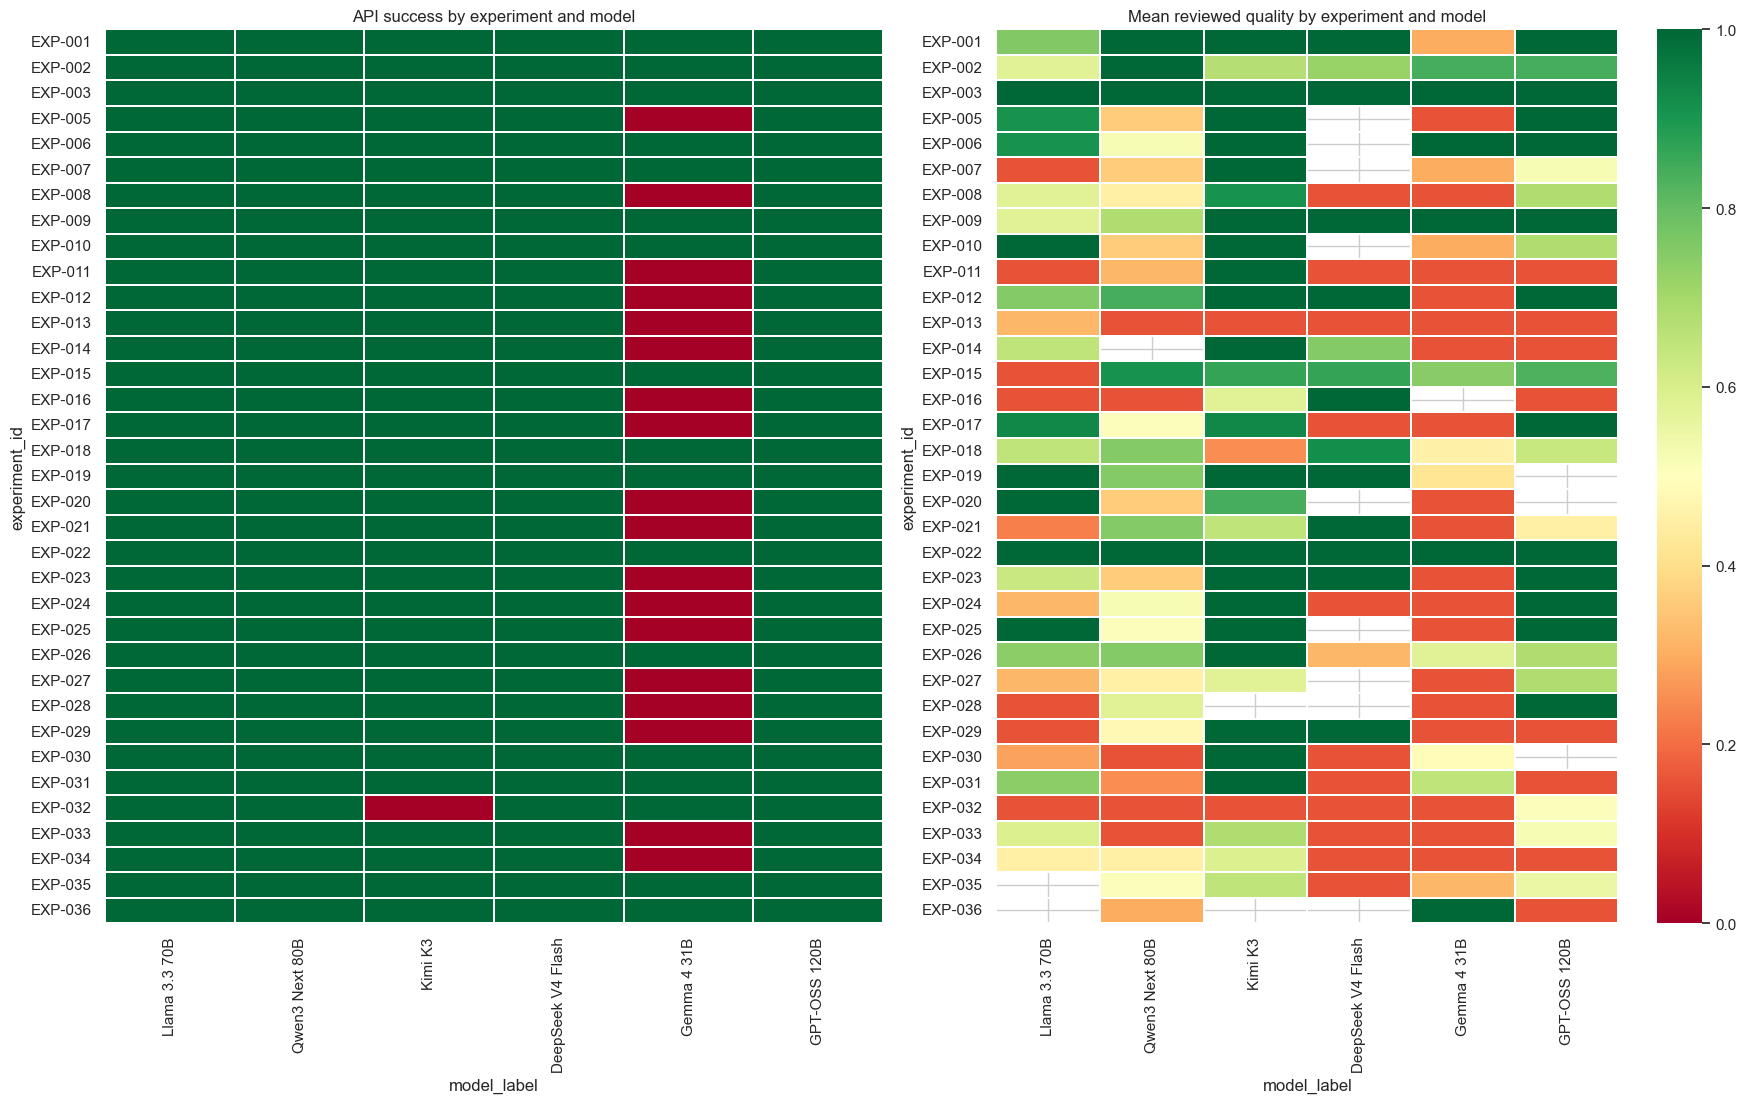

In [11]:
api_matrix = (df.pivot_table(
    index='experiment_id', columns='model_label', values='api_success', aggfunc='max'
).reindex(columns=MODEL_ORDER).astype(float))
quality_matrix = (df.pivot_table(
    index='experiment_id', columns='model_label', values='quality_score', aggfunc='mean'
).reindex(columns=MODEL_ORDER).astype(float))

fig, axes = plt.subplots(1, 2, figsize=(18, max(10, len(api_matrix) * 0.32)))
sns.heatmap(api_matrix, cmap='RdYlGn', vmin=0, vmax=1, linewidths=.3, ax=axes[0], cbar=False)
axes[0].set_title('API success by experiment and model')
sns.heatmap(quality_matrix, cmap='RdYlGn', vmin=0, vmax=1, linewidths=.3, ax=axes[1])
axes[1].set_title('Mean reviewed quality by experiment and model')
plt.tight_layout()


In [ ]:
# Overall score for each experiment-model pair. Repeated attempts are averaged within the pair.
pair_reliability = (df.groupby(['experiment_id', 'model_label'], observed=True)
    .agg(api_success_rate=('api_success', 'mean')))
pair_reviews = (df.loc[df['feedback_complete']]
    .groupby(['experiment_id', 'model_label'], observed=True)
    .agg(
        mean_functional_correctness=('functional_correctness', 'mean'),
        mean_intent_alignment=('intent_alignment', 'mean'),
        mean_outcome_score=('outcome_score', 'mean'),
    ))
pair_scores = pair_reliability.join(pair_reviews)
pair_scores['overall_score'] = (
    0.30 * pair_scores['api_success_rate'] +
    0.30 * (pair_scores['mean_functional_correctness'] / 5) +
    0.25 * (pair_scores['mean_intent_alignment'] / 5) +
    0.15 * pair_scores['mean_outcome_score']
)
experiment_model_score_matrix = (pair_scores['overall_score']
    .unstack('model_label')
    .reindex(columns=MODEL_ORDER)
    .sort_index())

display(
    experiment_model_score_matrix.style
        .format('{:.3f}', na_rep='Not reviewed')
        .background_gradient(cmap='RdYlGn', vmin=0, vmax=1, axis=None)
        .applymap(lambda value: 'background-color: #eeeeee; color: #666666' if pd.isna(value) else '')
        .set_properties(**{'text-align': 'center'})
        .set_caption('Overall score by experiment and model (0–1)')
)


## 8. Difficulty effects

,difficulty,model_label,trials,experiments,api_success_rate,error_rate,truncation_rate,reviewed_trials,mean_quality_score,mean_latency_ms
0,Easy,DeepSeek V4 Flash,16,8,100.0%,0.0%,56.2%,7,0.760,"29,587"
1,Easy,GPT-OSS 120B,14,8,100.0%,0.0%,0.0%,11,0.913,"4,601"
2,Easy,Gemma 4 31B,15,8,53.3%,46.7%,0.0%,13,0.482,"86,466"
3,Easy,Kimi K3,12,8,100.0%,0.0%,0.0%,8,0.948,"13,998"
4,Easy,Llama 3.3 70B,11,8,100.0%,0.0%,0.0%,9,0.692,"4,076"
5,Easy,Qwen3 Next 80B,10,8,100.0%,0.0%,0.0%,8,0.671,"6,264"
6,Medium,DeepSeek V4 Flash,29,20,100.0%,0.0%,41.4%,19,0.707,"29,081"
7,Medium,GPT-OSS 120B,43,20,100.0%,0.0%,11.6%,20,0.661,"5,177"
8,Medium,Gemma 4 31B,24,20,29.2%,70.8%,0.0%,22,0.315,"98,888"
9,Medium,Kimi K3,30,20,100.0%,0.0%,10.0%,21,0.844,"33,635"


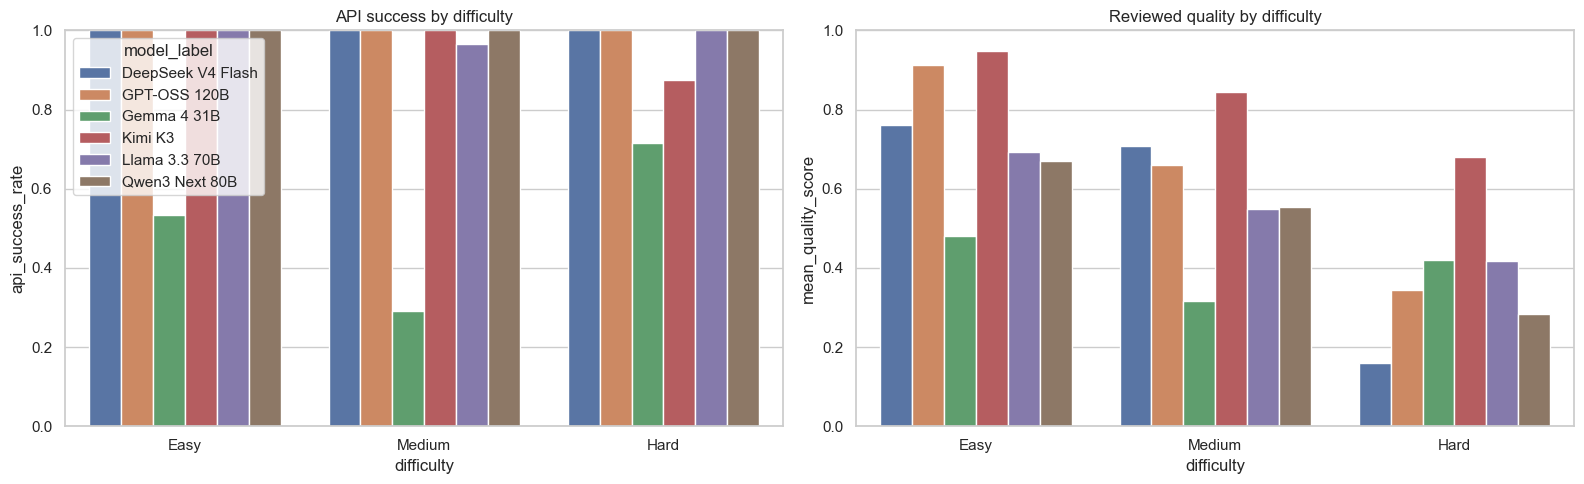

In [12]:
difficulty_summary = (df.groupby(['difficulty', 'model_label'], observed=True)
    .agg(
        trials=('request_id', 'count'),
        experiments=('experiment_id', 'nunique'),
        api_success_rate=('api_success', 'mean'),
        error_rate=('api_error', 'mean'),
        truncation_rate=('truncated', 'mean'),
        reviewed_trials=('quality_score', 'count'),
        mean_quality_score=('quality_score', 'mean'),
        mean_latency_ms=('latency_ms', 'mean'),
    )
    .reset_index())
display(difficulty_summary.style.format({
    'api_success_rate': '{:.1%}', 'error_rate': '{:.1%}', 'truncation_rate': '{:.1%}',
    'mean_quality_score': '{:.3f}', 'mean_latency_ms': '{:,.0f}',
}))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=difficulty_summary, x='difficulty', y='api_success_rate', hue='model_label', ax=axes[0])
axes[0].set_ylim(0, 1); axes[0].set_title('API success by difficulty')
sns.barplot(data=difficulty_summary, x='difficulty', y='mean_quality_score', hue='model_label', ax=axes[1])
axes[1].set_ylim(0, 1); axes[1].set_title('Reviewed quality by difficulty')
axes[1].legend_.remove()
plt.tight_layout()


## 9. Repeatability and multiple-trial reliability

This section isolates model–experiment pairs with repeated trials and measures whether repeated attempts agree.

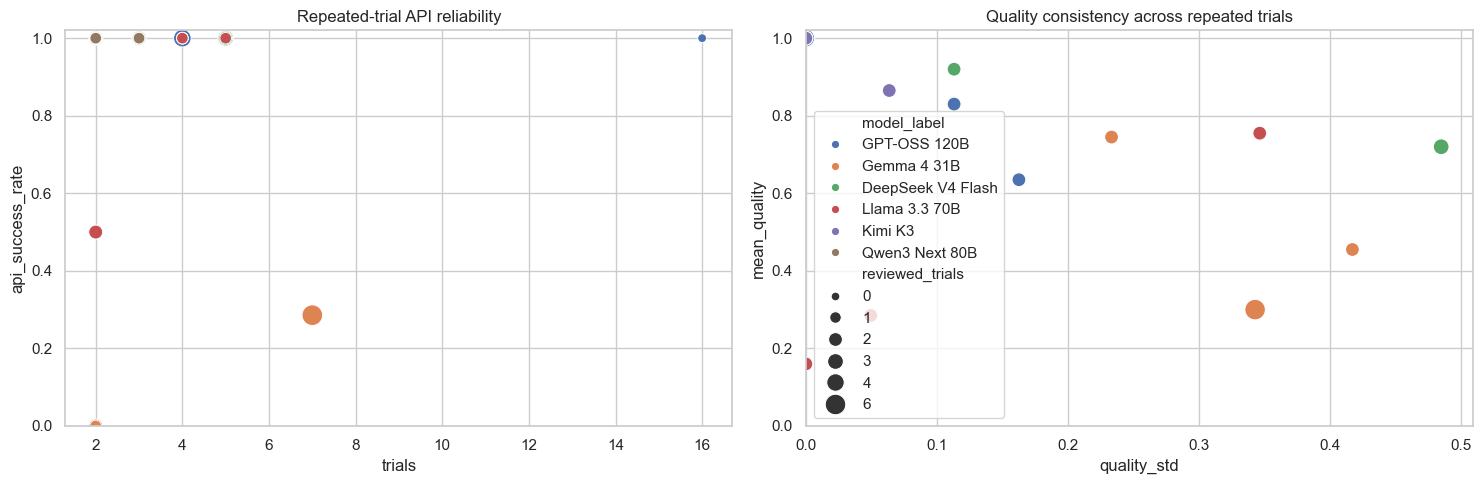

In [13]:
repeatability = (df.groupby(['model_label', 'experiment_id'], observed=True)
    .agg(
        trials=('request_id', 'count'),
        api_success_rate=('api_success', 'mean'),
        reviewed_trials=('quality_score', 'count'),
        mean_quality=('quality_score', 'mean'),
        quality_std=('quality_score', 'std'),
        outcome_variants=('outcome_normalized', lambda values: values[values.ne('')].nunique()),
        latency_cv=('latency_ms', lambda values: values.std() / values.mean() if values.count() > 1 and values.mean() else np.nan),
    )
    .query('trials > 1')
    .sort_values(['trials', 'quality_std'], ascending=[False, False]))
display(repeatability.style.format({
    'api_success_rate': '{:.1%}', 'mean_quality': '{:.3f}',
    'quality_std': '{:.3f}', 'latency_cv': '{:.2f}',
}))

if len(repeatability):
    repeat_plot = repeatability.reset_index()
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.scatterplot(
        data=repeat_plot, x='trials', y='api_success_rate', hue='model_label',
        size='reviewed_trials', sizes=(40, 220), ax=axes[0]
    )
    axes[0].set_ylim(0, 1.02)
    axes[0].set_title('Repeated-trial API reliability')
    sns.scatterplot(
        data=repeat_plot, x='quality_std', y='mean_quality', hue='model_label',
        size='reviewed_trials', sizes=(40, 220), ax=axes[1]
    )
    axes[1].set_xlim(left=0); axes[1].set_ylim(0, 1.02)
    axes[1].set_title('Quality consistency across repeated trials')
    axes[0].legend_.remove()
    plt.tight_layout()


## 10. Efficiency: quality, latency, and token usage

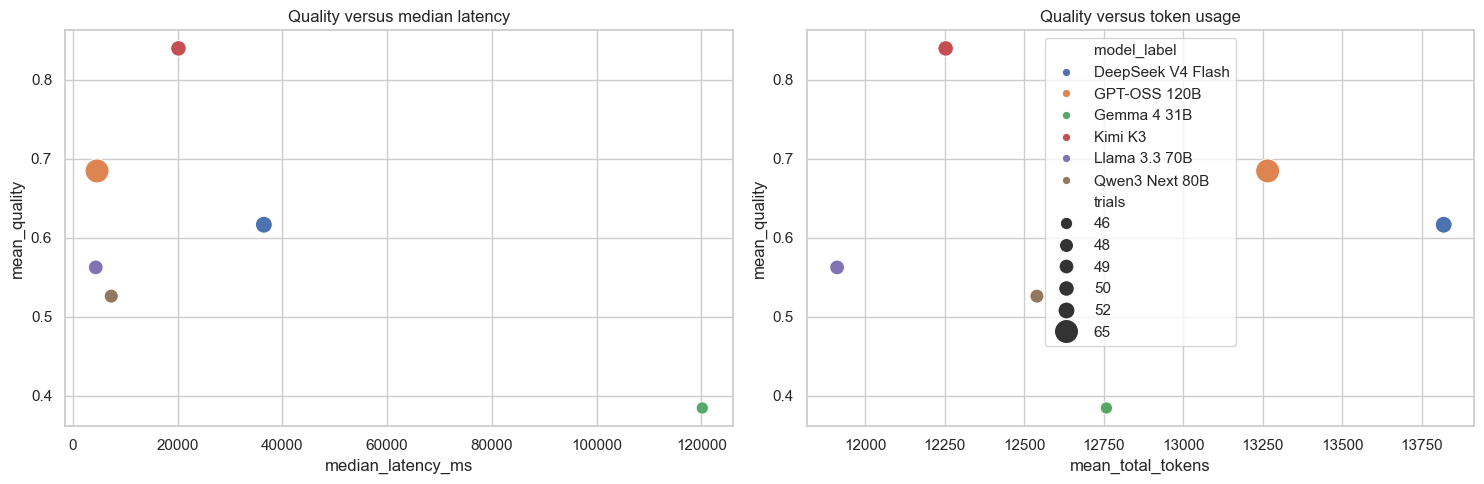

In [14]:
efficiency = (df.groupby('model_label', observed=True)
    .agg(
        mean_quality=('quality_score', 'mean'),
        median_latency_ms=('latency_ms', 'median'),
        mean_total_tokens=('total_tokens', 'mean'),
        trials=('request_id', 'count'),
    )
    .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=efficiency, x='median_latency_ms', y='mean_quality', hue='model_label',
                size='trials', sizes=(80, 300), ax=axes[0])
axes[0].set_title('Quality versus median latency')
sns.scatterplot(data=efficiency, x='mean_total_tokens', y='mean_quality', hue='model_label',
                size='trials', sizes=(80, 300), ax=axes[1])
axes[1].set_title('Quality versus token usage')
axes[0].legend_.remove()
plt.tight_layout()


## 11. Token usage and estimated price

Token counts come from each stored API response. Current provider prices are requested from Hugging Face's public `https://router.huggingface.co/v1/models` endpoint, where input and output prices are expressed in USD per million tokens. Current prices estimate cost; they are not guaranteed to match historical billing. For actual charges, use the Hugging Face billing usage page: https://huggingface.co/settings/billing.

`InferenceClient(bill_to='my-org-name')` only chooses which account is billed for new requests. It does not retrieve prices, usage, invoices, or per-request costs.

If live pricing is unavailable, add rates to `MANUAL_PRICES` below using the provider comparison page: https://huggingface.co/inference/models.

,model_id,pricing_provider,input_usd_per_million,output_usd_per_million,provider_status,price_source
3,Qwen/Qwen3-Next-80B-A3B-Instruct,novita,NaN,NaN,NaN,NaN
1,deepseek-ai/DeepSeek-V4-Flash-0731,novita,NaN,NaN,NaN,NaN
4,google/gemma-4-31B-it,novita,NaN,NaN,NaN,NaN
2,meta-llama/Llama-3.3-70B-Instruct,groq,NaN,NaN,NaN,NaN
0,moonshotai/Kimi-K3,together,NaN,NaN,NaN,NaN
5,openai/gpt-oss-120b,groq,NaN,NaN,NaN,NaN


**Live Hugging Face pricing could not be loaded:** `<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)>`. Use `MANUAL_PRICES`.

**Missing published prices:** add these model/provider pairs to `MANUAL_PRICES`.

,model_id,pricing_provider
0,moonshotai/Kimi-K3,together
1,deepseek-ai/DeepSeek-V4-Flash-0731,novita
2,meta-llama/Llama-3.3-70B-Instruct,groq
3,Qwen/Qwen3-Next-80B-A3B-Instruct,novita
4,google/gemma-4-31B-it,novita
5,openai/gpt-oss-120b,groq


,trials,prompt_tokens,completion_tokens,total_tokens,mean_tokens_per_trial,p95_tokens_per_trial,priced_trials,estimated_input_cost_usd,estimated_output_cost_usd,estimated_cost_usd,price_coverage,cost_per_trial_usd
model_label,,,,,,,,,,,,
Llama 3.3 70B,49,"496,487","75,295","571,782","11,912","14,169",0,$0.0000,$0.0000,$0.0000,0.0%,$nan
Qwen3 Next 80B,48,"513,607","88,332","601,939","12,540","14,755",0,$0.0000,$0.0000,$0.0000,0.0%,$nan
Kimi K3,50,"511,853","88,567","600,420","12,253","14,457",0,$0.0000,$0.0000,$0.0000,0.0%,$nan
DeepSeek V4 Flash,52,"551,966","166,643","718,609","13,819","14,914",0,$0.0000,$0.0000,$0.0000,0.0%,$nan
Gemma 4 31B,46,"232,968","22,209","255,177","12,759","15,181",0,$0.0000,$0.0000,$0.0000,0.0%,$nan
GPT-OSS 120B,65,"723,400","138,884","862,284","13,266","17,710",0,$0.0000,$0.0000,$0.0000,0.0%,$nan


,experiment_id,difficulty,trials,total_tokens,estimated_cost_usd,mean_quality
0,EXP-001,Easy,16,124458.0,0,0.687333
26,EXP-028,Medium,8,71912.0,0,0.412000
20,EXP-022,Medium,6,67019.0,0,1.000000
21,EXP-023,Medium,10,97475.0,0,0.663750
22,EXP-024,Medium,7,84982.0,0,0.526667
23,EXP-025,Medium,6,58942.0,0,0.734000
24,EXP-026,Medium,6,69239.0,0,0.678333
25,EXP-027,Medium,10,121475.0,0,0.438000
27,EXP-029,Medium,13,145462.0,0,0.493333
18,EXP-020,Medium,7,87675.0,0,0.590000


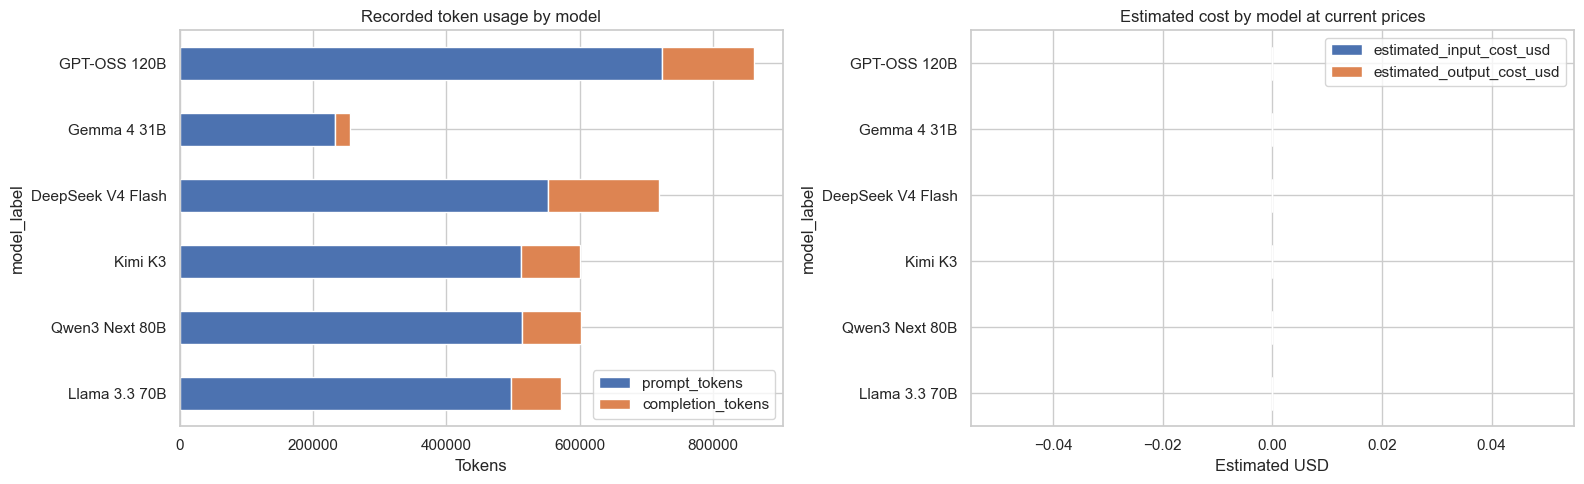

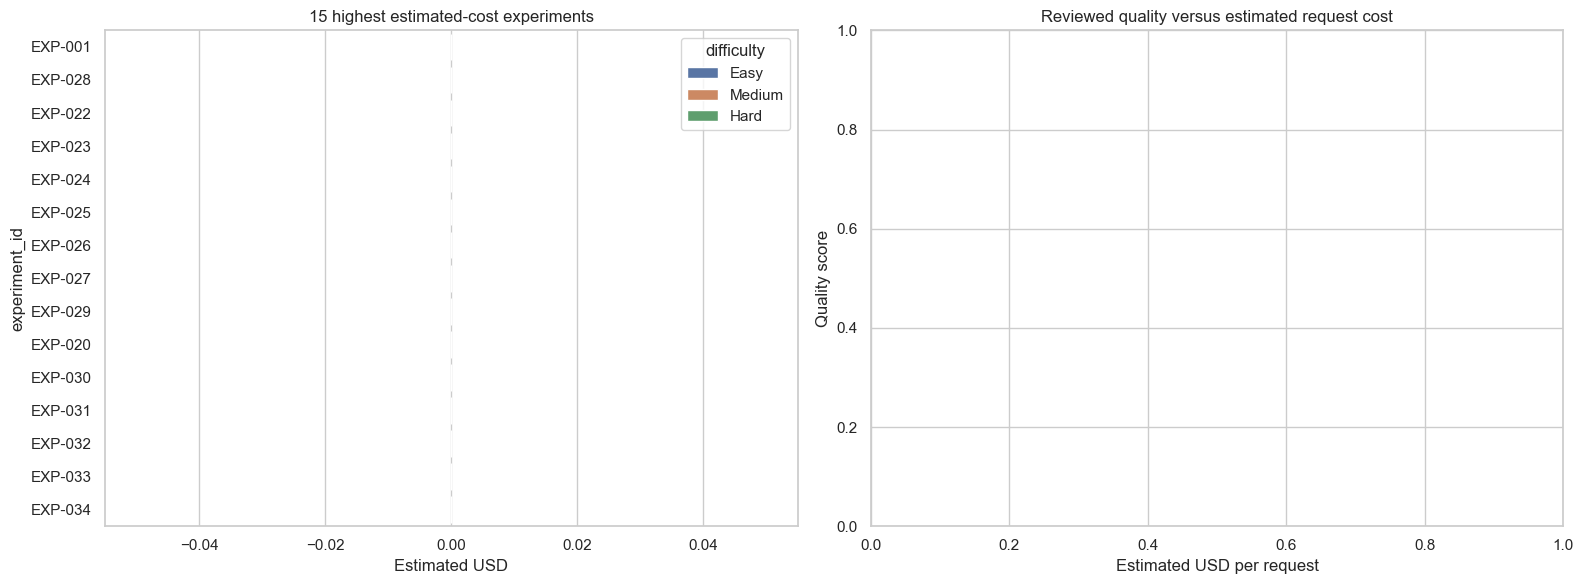

In [15]:
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen

HF_MODELS_URL = 'https://router.huggingface.co/v1/models'
HF_TOKEN = os.getenv('HF_TOKEN') or os.getenv('HUGGINGFACE_TOKEN')
FETCH_LIVE_HF_PRICES = True

# Optional fallback for models/providers without a published live rate.
# Values are USD per one million tokens. Example:
# MANUAL_PRICES = [
#     {'model_id': 'owner/model', 'pricing_provider': 'provider',
#      'input_usd_per_million': 0.20, 'output_usd_per_million': 0.80},
# ]
MANUAL_PRICES = []

def fetch_hf_prices():
    headers = {'Accept': 'application/json', 'User-Agent': 'scratch-vibe-experiment-analysis'}
    if HF_TOKEN:
        headers['Authorization'] = f'Bearer {HF_TOKEN}'
    request = Request(HF_MODELS_URL, headers=headers)
    with urlopen(request, timeout=30) as response:
        payload = json.load(response)
    records = []
    for model_info in payload.get('data', []):
        for provider_info in model_info.get('providers', []):
            pricing = provider_info.get('pricing') or {}
            if pricing.get('input') is None or pricing.get('output') is None:
                continue
            records.append({
                'model_id': model_info.get('id'),
                'pricing_provider': str(provider_info.get('provider', '')).lower(),
                'input_usd_per_million': pd.to_numeric(pricing.get('input'), errors='coerce'),
                'output_usd_per_million': pd.to_numeric(pricing.get('output'), errors='coerce'),
                'provider_status': provider_info.get('status'),
                'price_source': 'Hugging Face router (current)',
            })
    return pd.DataFrame(records)

price_columns = [
    'model_id', 'pricing_provider', 'input_usd_per_million',
    'output_usd_per_million', 'provider_status', 'price_source'
]
live_prices = pd.DataFrame(columns=price_columns)
pricing_error = None
if FETCH_LIVE_HF_PRICES:
    try:
        live_prices = fetch_hf_prices().reindex(columns=price_columns)
    except (HTTPError, URLError, TimeoutError, ValueError, json.JSONDecodeError) as error:
        pricing_error = str(error)

manual_prices = pd.DataFrame(MANUAL_PRICES)
if len(manual_prices):
    manual_prices['provider_status'] = 'manual'
    manual_prices['price_source'] = 'Manual fallback'
    manual_prices = manual_prices.reindex(columns=price_columns)
prices = pd.concat([live_prices, manual_prices], ignore_index=True)
prices = prices.drop_duplicates(['model_id', 'pricing_provider'], keep='last')

model_parts = df['model'].str.rsplit(':', n=1, expand=True)
df['model_id'] = model_parts[0]
df['pricing_provider'] = model_parts[1].str.lower()
df = df.drop(columns=[
    'input_usd_per_million', 'output_usd_per_million', 'provider_status', 'price_source'
], errors='ignore').merge(prices, on=['model_id', 'pricing_provider'], how='left')

df['estimated_input_cost_usd'] = (
    df['prompt_tokens'] * df['input_usd_per_million'] / 1_000_000
)
df['estimated_output_cost_usd'] = (
    df['completion_tokens'] * df['output_usd_per_million'] / 1_000_000
)
df['estimated_cost_usd'] = df['estimated_input_cost_usd'] + df['estimated_output_cost_usd']
df['priced_record'] = df['estimated_cost_usd'].notna()

used_pairs = df[['model_id', 'pricing_provider']].drop_duplicates()
price_coverage = used_pairs.merge(prices, on=['model_id', 'pricing_provider'], how='left')
display(price_coverage.sort_values(['model_id', 'pricing_provider']))
if pricing_error:
    display(Markdown(f'**Live Hugging Face pricing could not be loaded:** `{pricing_error}`. Use `MANUAL_PRICES`.'))
missing_price_pairs = price_coverage[price_coverage['input_usd_per_million'].isna()]
if len(missing_price_pairs):
    display(Markdown('**Missing published prices:** add these model/provider pairs to `MANUAL_PRICES`.'))
    display(missing_price_pairs[['model_id', 'pricing_provider']])

token_cost_by_model = (df.groupby('model_label', observed=True)
    .agg(
        trials=('request_id', 'count'),
        prompt_tokens=('prompt_tokens', 'sum'),
        completion_tokens=('completion_tokens', 'sum'),
        total_tokens=('total_tokens', 'sum'),
        mean_tokens_per_trial=('total_tokens', 'mean'),
        p95_tokens_per_trial=('total_tokens', lambda values: values.quantile(0.95)),
        priced_trials=('priced_record', 'sum'),
        estimated_input_cost_usd=('estimated_input_cost_usd', 'sum'),
        estimated_output_cost_usd=('estimated_output_cost_usd', 'sum'),
        estimated_cost_usd=('estimated_cost_usd', 'sum'),
    )
    .reindex(MODEL_ORDER))
token_cost_by_model['price_coverage'] = token_cost_by_model['priced_trials'] / token_cost_by_model['trials']
token_cost_by_model['cost_per_trial_usd'] = token_cost_by_model['estimated_cost_usd'] / token_cost_by_model['priced_trials'].replace(0, np.nan)
display(token_cost_by_model.style.format({
    'prompt_tokens': '{:,.0f}', 'completion_tokens': '{:,.0f}', 'total_tokens': '{:,.0f}',
    'mean_tokens_per_trial': '{:,.0f}', 'p95_tokens_per_trial': '{:,.0f}',
    'price_coverage': '{:.1%}', 'estimated_input_cost_usd': '${:,.4f}',
    'estimated_output_cost_usd': '${:,.4f}', 'estimated_cost_usd': '${:,.4f}',
    'cost_per_trial_usd': '${:,.5f}',
}))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
token_cost_by_model[['prompt_tokens', 'completion_tokens']].plot.barh(
    stacked=True, ax=axes[0], title='Recorded token usage by model'
)
axes[0].set_xlabel('Tokens')
token_cost_by_model[['estimated_input_cost_usd', 'estimated_output_cost_usd']].plot.barh(
    stacked=True, ax=axes[1], title='Estimated cost by model at current prices'
)
axes[1].set_xlabel('Estimated USD')
plt.tight_layout()

cost_by_experiment = (df.groupby(['experiment_id', 'difficulty'], observed=True)
    .agg(
        trials=('request_id', 'count'),
        total_tokens=('total_tokens', 'sum'),
        estimated_cost_usd=('estimated_cost_usd', 'sum'),
        mean_quality=('quality_score', 'mean'),
    )
    .reset_index())
display(cost_by_experiment.sort_values('estimated_cost_usd', ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=cost_by_experiment.sort_values('estimated_cost_usd', ascending=False).head(15),
    y='experiment_id', x='estimated_cost_usd', hue='difficulty', dodge=False, ax=axes[0]
)
axes[0].set_title('15 highest estimated-cost experiments')
axes[0].set_xlabel('Estimated USD')
sns.scatterplot(
    data=df, x='estimated_cost_usd', y='quality_score', hue='model_label',
    style='difficulty', s=80, ax=axes[1]
)
axes[1].set_title('Reviewed quality versus estimated request cost')
axes[1].set_xlabel('Estimated USD per request')
axes[1].set_ylabel('Quality score')
plt.tight_layout()


## 12. Automatically generated findings

In [16]:
findings = []
if reliability['api_success_rate'].notna().any():
    best_reliability = reliability['api_success_rate'].idxmax()
    findings.append(f"Highest API success rate: **{best_reliability}** ({reliability.loc[best_reliability, 'api_success_rate']:.1%}).")
    lowest_reliability = reliability['api_success_rate'].idxmin()
    findings.append(f"Lowest API success rate: **{lowest_reliability}** ({reliability.loc[lowest_reliability, 'api_success_rate']:.1%}).")
if quality['overall_model_score'].notna().any():
    leader = quality['overall_model_score'].idxmax()
    findings.append(f"Highest weighted overall score: **{leader}** ({quality.loc[leader, 'overall_model_score']:.3f}).")
if df['truncated'].any():
    trunc = df.loc[df.truncated].groupby('model_label').size().sort_values(ascending=False)
    findings.append('Truncated responses by model: ' + ', '.join(f'**{model}**={count}' for model, count in trunc.items()) + '.')
if len(coverage_gaps):
    findings.append(f"Record coverage is incomplete for **{len(coverage_gaps)}** included experiment(s).")
else:
    findings.append('All included experiments have at least one record for every model.')
findings.append(f"Feedback is present for **{df.has_any_feedback.mean():.1%}** of trials; quality rankings should be interpreted with this coverage in mind.")
display(Markdown('\n'.join(f'- {finding}' for finding in findings)))


- Highest API success rate: **Qwen3 Next 80B** (100.0%).
- Lowest API success rate: **Gemma 4 31B** (43.5%).
- Highest weighted overall score: **Kimi K3** (0.882).
- Truncated responses by model: **DeepSeek V4 Flash**=28, **GPT-OSS 120B**=11, **Kimi K3**=9, **Qwen3 Next 80B**=9, **Llama 3.3 70B**=3, **Gemma 4 31B**=1.
- All included experiments have at least one record for every model.
- Feedback is present for **69.7%** of trials; quality rankings should be interpreted with this coverage in mind.

## 13. Optional exports

Set `EXPORT_RESULTS = True` to write analysis-ready CSV tables.

In [17]:
EXPORT_RESULTS = False
if EXPORT_RESULTS:
    output_dir = Path('../analysis_outputs')
    output_dir.mkdir(parents=True, exist_ok=True)
    trials_by_model.to_csv(output_dir / 'trials_by_model.csv')
    reliability.to_csv(output_dir / 'model_reliability.csv')
    quality.to_csv(output_dir / 'model_quality_and_scores.csv')
    experiment_summary.to_csv(output_dir / 'experiment_summary.csv')
    difficulty_summary.to_csv(output_dir / 'difficulty_summary.csv', index=False)
    repeatability.to_csv(output_dir / 'repeatability.csv')
    error_details.to_csv(output_dir / 'error_details.csv', index=False)
    price_coverage.to_csv(output_dir / 'huggingface_price_coverage.csv', index=False)
    token_cost_by_model.to_csv(output_dir / 'token_cost_by_model.csv')
    cost_by_experiment.to_csv(output_dir / 'token_cost_by_experiment.csv', index=False)
    print(f'Exported analysis tables to {output_dir.resolve()}')


## Interpretation checklist

- Compare model quality only when review coverage is reasonably similar.
- Keep API errors, truncated responses, and reviewer-assessed failures separate.
- Do not treat repeated attempts as independent experiments when making inferential claims.
- Inspect model × experiment heatmaps before trusting an overall average; one task family can dominate a ranking.
- Report the number of reviewed trials beside every quality score.
- Re-run the notebook after feedback updates so quality and outcome metrics remain current.